In [1]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from importlib.metadata import version

sc.settings.verbosity = 3
sc.settings.set_figure_params(
    dpi=120,
    facecolor="white",
    frameon=False
)

print("Scanpy version:", version("scanpy"))
print("AnnData version:", version("anndata"))

Scanpy version: 1.11.5
AnnData version: 0.12.19


In [6]:
data_dir = Path("../data")

print("Data directory:", data_dir.resolve())
print("Exists:", data_dir.exists())

Data directory: /media/nabil/ssd/sc-project3-IFN-I/data
Exists: True


In [7]:
data_dir = Path("../data")

print("Data directory:", data_dir.resolve())
print("Exists:", data_dir.exists())

sample_dirs = sorted([
    p for p in data_dir.iterdir()
    if p.is_dir() and (p / "matrix.mtx.gz").exists()
])

print("Samples found:", [p.name for p in sample_dirs])

Data directory: /media/nabil/ssd/sc-project3-IFN-I/data
Exists: True
Samples found: ['HD1', 'HD2', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8']


In [8]:
adatas = {}

for sample_path in sample_dirs:
    sample_id = sample_path.name

    print(f"Loading {sample_id}...")

    adata_sample = sc.read_10x_mtx(
        path=sample_path,
        var_names="gene_symbols",
        cache=False
    )

    adata_sample.obs["sample"] = sample_id

    if sample_id.startswith("HD"):
        adata_sample.obs["donor_type"] = "Healthy_Donor"
    else:
        adata_sample.obs["donor_type"] = "Patient"

    adatas[sample_id] = adata_sample

print("Finished loading all samples.")

Loading HD1...
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading HD2...
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading P1...
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading P2...
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading P3...
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading P4...
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading P5...
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading from a cache file.
Loading P6...
--> This might be very slow. Consider passing `cache=True`, which enables much faster reading f

In [5]:
for sample_id, adata_sample in adatas.items():
    print(
        f"{sample_id}: "
        f"{adata_sample.n_obs:,} cells × "
        f"{adata_sample.n_vars:,} genes"
    )

HD1: 7,565 cells × 36,601 genes
HD2: 11,952 cells × 36,601 genes
P1: 10,845 cells × 36,601 genes
P2: 14,493 cells × 36,601 genes
P3: 13,010 cells × 36,601 genes
P4: 10,787 cells × 36,601 genes
P5: 2,992 cells × 36,601 genes
P6: 9,948 cells × 36,601 genes
P7: 9,704 cells × 36,601 genes
P8: 9,724 cells × 36,601 genes


In [9]:
adata = ad.concat(
    adatas,
    label="sample_batch",
    index_unique="-",
    join="outer"
)

adata.var_names_make_unique()

print(
    f"Merged dataset: "
    f"{adata.n_obs:,} cells × {adata.n_vars:,} genes"
)

Merged dataset: 101,020 cells × 36,601 genes


In [7]:
adata

AnnData object with n_obs × n_vars = 101020 × 36601
    obs: 'sample', 'donor_type', 'sample_batch'

In [8]:
adata.obs.head()

,sample,donor_type,sample_batch
AAACAGCCAAACTCAT-1-HD1,HD1,Healthy_Donor,HD1
AAACAGCCAATTAACC-1-HD1,HD1,Healthy_Donor,HD1
AAACAGCCACAATACT-1-HD1,HD1,Healthy_Donor,HD1
AAACAGCCACTAAGCC-1-HD1,HD1,Healthy_Donor,HD1
AAACAGCCAGATAGAC-1-HD1,HD1,Healthy_Donor,HD1


In [9]:
adata.obs.tail()

,sample,donor_type,sample_batch
TTTGTTGGTCCGTAGG-1-P8,P8,Patient,P8
TTTGTTGGTCCTTAGT-1-P8,P8,Patient,P8
TTTGTTGGTTAACAGT-1-P8,P8,Patient,P8
TTTGTTGGTTGCAATG-1-P8,P8,Patient,P8
TTTGTTGGTTTATTCG-1-P8,P8,Patient,P8


In [12]:
from pathlib import Path

output_dir = Path("../results/preprocessing")
output_dir.mkdir(parents=True, exist_ok=True)

In [13]:
adata.write_h5ad(output_dir / "merged_raw.h5ad")

In [14]:
merged_file = output_dir / "merged_raw.h5ad"

print("Saved:", merged_file.resolve())
print(f"File size: {merged_file.stat().st_size / 1024**2:.2f} MB")

Saved: /media/nabil/ssd/sc-project3-IFN-I/results/preprocessing/merged_raw.h5ad
File size: 1568.65 MB


In [10]:
adata.obs

,sample,donor_type,sample_batch
AAACAGCCAAACTCAT-1-HD1,HD1,Healthy_Donor,HD1
AAACAGCCAATTAACC-1-HD1,HD1,Healthy_Donor,HD1
AAACAGCCACAATACT-1-HD1,HD1,Healthy_Donor,HD1
AAACAGCCACTAAGCC-1-HD1,HD1,Healthy_Donor,HD1
AAACAGCCAGATAGAC-1-HD1,HD1,Healthy_Donor,HD1
...,...,...,...
TTTGTTGGTCCGTAGG-1-P8,P8,Patient,P8
TTTGTTGGTCCTTAGT-1-P8,P8,Patient,P8
TTTGTTGGTTAACAGT-1-P8,P8,Patient,P8
TTTGTTGGTTGCAATG-1-P8,P8,Patient,P8


In [10]:
# Identify gene families used for QC
adata.var["mt"] = adata.var_names.str.startswith("MT-")

adata.var["ribo"] = adata.var_names.str.startswith(
    ("RPS", "RPL")
)

adata.var["hb"] = adata.var_names.str.startswith(
    ("HBA", "HBB", "HBD", "HBE", "HBG", "HBM", "HBQ", "HBZ")
)

print("Mitochondrial genes:", adata.var["mt"].sum())
print("Ribosomal genes:", adata.var["ribo"].sum())
print("Hemoglobin genes:", adata.var["hb"].sum())

Mitochondrial genes: 13
Ribosomal genes: 103
Hemoglobin genes: 11


In [11]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True
)

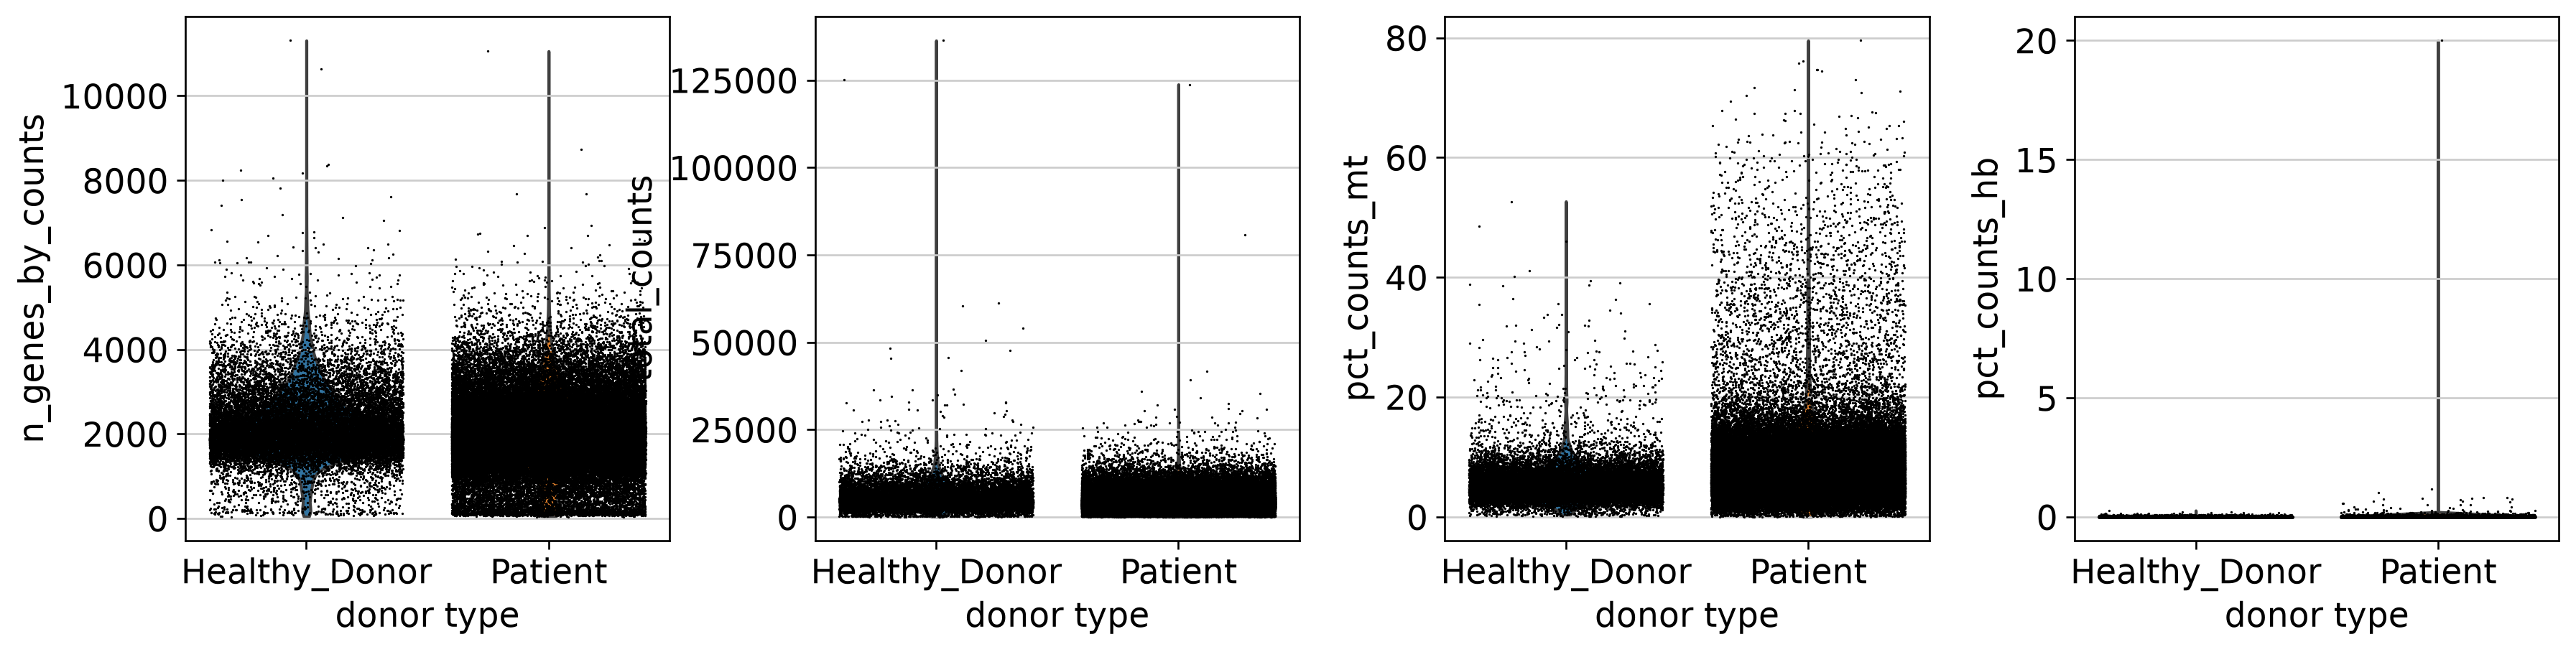

In [12]:
sc.pl.violin(
    adata,
    [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "pct_counts_hb"
    ],
    groupby="donor_type",
    jitter=0.4,
    multi_panel=True
)

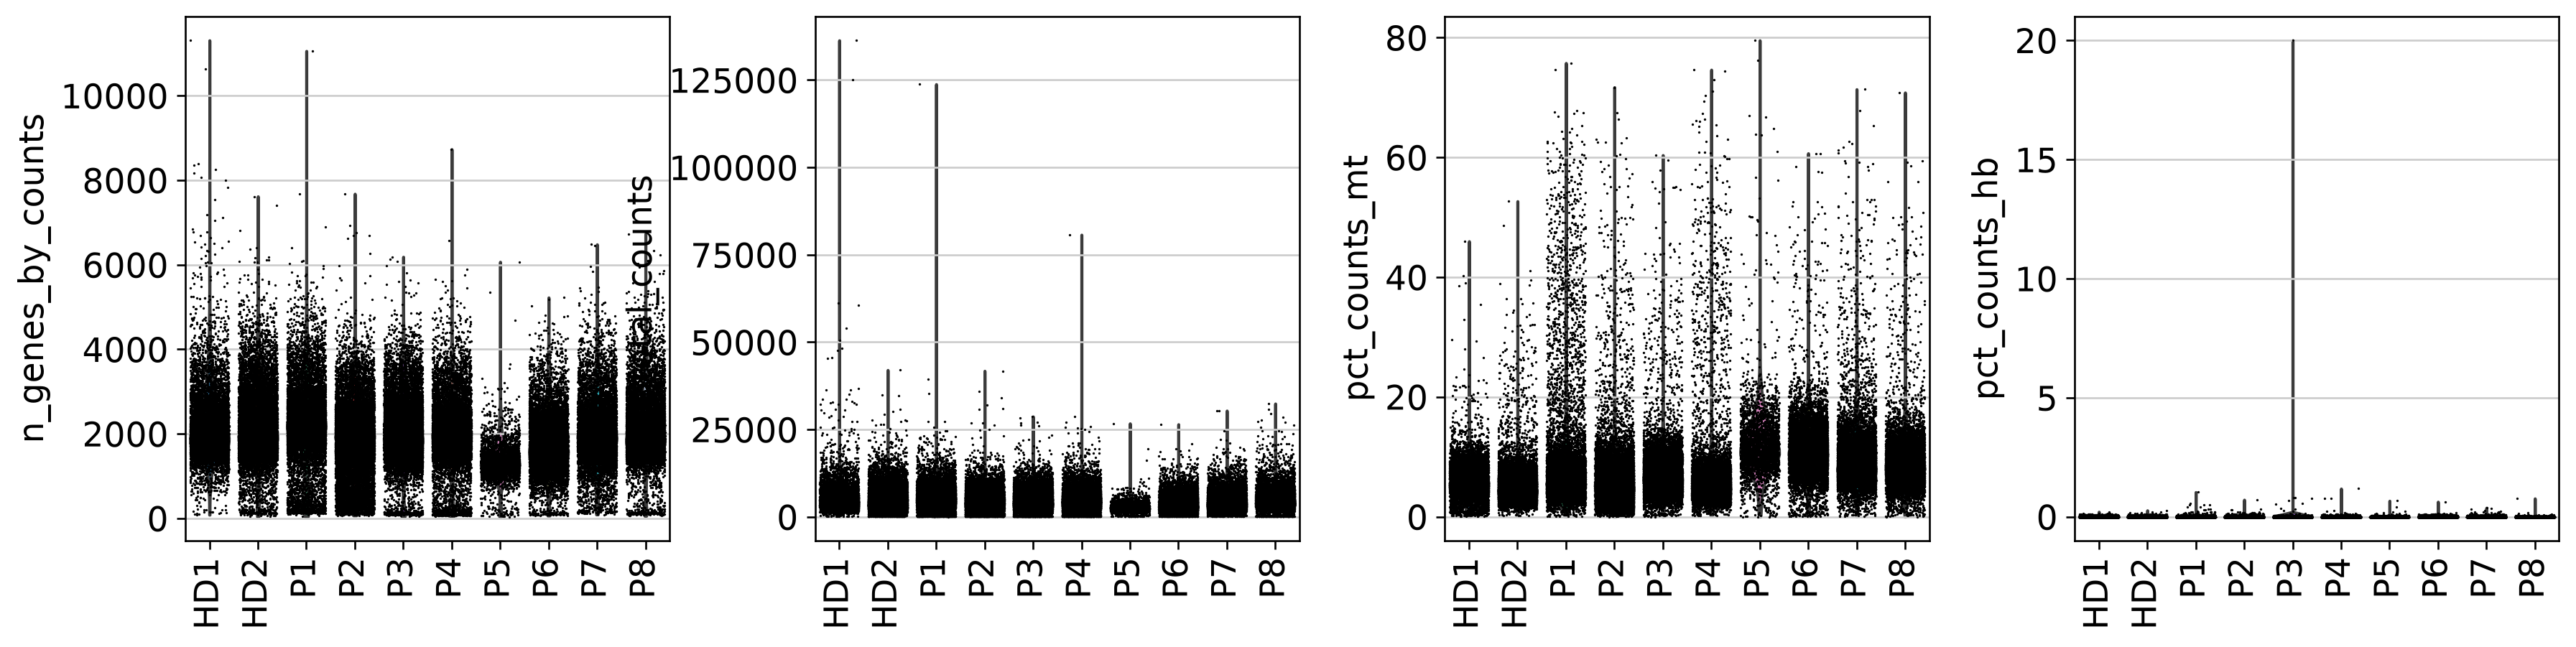

In [13]:
sc.pl.violin(
    adata,
    [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "pct_counts_hb"
    ],
    groupby="sample",
    jitter=0.4,
    multi_panel=True,
    rotation=90
)

In [10]:
adata.obs[
    [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "pct_counts_ribo",
        "pct_counts_hb"
    ]
].describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo,pct_counts_hb
count,101020.000000,101020.000000,101020.000000,101020.000000,101020.000000
mean,2024.614344,4746.331543,7.841968,3.282089,0.002825
std,773.474282,2904.851562,5.931536,3.074897,0.064613
min,37.000000,41.000000,0.000000,0.000000,0.000000
25%,1609.000000,3111.000000,4.638738,1.301058,0.000000
50%,1967.000000,4207.000000,6.572817,2.324680,0.000000
75%,2385.000000,5746.000000,9.338955,4.199184,0.000000
max,11307.000000,136340.000000,79.525482,53.267567,20.000000


In [11]:
qc_summary = (
    adata.obs
    .groupby("sample")
    [
        [
            "n_genes_by_counts",
            "total_counts",
            "pct_counts_mt",
            "pct_counts_hb"
        ]
    ]
    .median()
)

qc_summary

/tmp/ipykernel_4017/3882379110.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample")


,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_hb
sample,,,,
HD1,2033.0,4412.0,5.821004,0.0
HD2,2068.0,4194.0,4.636642,0.0
P1,2245.0,5049.0,6.135209,0.0
P2,1909.0,4022.0,5.011136,0.0
P3,1996.5,4317.0,6.621499,0.0
P4,1984.0,4513.0,5.272609,0.0
P5,1298.0,2545.0,11.416914,0.0
P6,1678.0,3454.5,10.859177,0.0
P7,1960.5,3965.5,8.808832,0.0


In [12]:
# Record cell count before filtering
n_before = adata.n_obs

# Filter cells with too few detected genes
sc.pp.filter_cells(adata, min_genes=300)

# Remove high mitochondrial cells
adata = adata[
    adata.obs["pct_counts_mt"] < 15.0,
    :
].copy()

# Remove cells with high hemoglobin contamination
adata = adata[
    adata.obs["pct_counts_hb"] < 5.0,
    :
].copy()

n_after = adata.n_obs

print(f"Cells before QC: {n_before:,}")
print(f"Cells after QC:  {n_after:,}")
print(f"Cells removed:   {n_before - n_after:,}")
print(f"Retention:       {n_after / n_before * 100:.2f}%")

filtered out 2194 cells that have less than 300 genes expressed
Cells before QC: 101,020
Cells after QC:  94,513
Cells removed:   6,507
Retention:       93.56%


In [19]:
n_genes_before = adata.n_vars

sc.pp.filter_genes(
    adata,
    min_cells=5
)

n_genes_after = adata.n_vars

print(f"Genes before filtering: {n_genes_before:,}")
print(f"Genes after filtering:  {n_genes_after:,}")
print(f"Genes removed:          {n_genes_before - n_genes_after:,}")

filtered out 5547 genes that are detected in less than 5 cells
Genes before filtering: 36,601
Genes after filtering:  31,054
Genes removed:          5,547


In [20]:
adata

AnnData object with n_obs × n_vars = 94513 × 31054
    obs: 'sample', 'donor_type', 'sample_batch', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_genes'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'donor_type_colors', 'sample_colors'

In [21]:
print(
    adata.obs["sample"].value_counts().sort_index()
)

sample
HD1     7482
HD2    11694
P1      9718
P2     13774
P3     12590
P4     10194
P5      2357
P6      8644
P7      8850
P8      9210
Name: count, dtype: int64


In [11]:
output_dir = Path("../results/preprocessing")
output_dir.mkdir(parents=True, exist_ok=True)

adata.write_h5ad(
    output_dir / "merged_qc_filtered.h5ad"
)

print(
    "Saved:",
    (output_dir / "merged_qc_filtered.h5ad").resolve()
)

Saved: /media/nabil/ssd/sc-project3-IFN-I/results/preprocessing/merged_qc_filtered.h5ad


In [2]:
# Path to the QC-filtered AnnData file
qc_file = Path(
    "/media/nabil/ssd/sc-project3-IFN-I/results/preprocessing/merged_qc_filtered.h5ad"
)

# Load the dataset
adata = sc.read_h5ad(qc_file)

print("Loaded:", qc_file)
print(
    f"Dataset: {adata.n_obs:,} cells × "
    f"{adata.n_vars:,} genes"
)

Loaded: /media/nabil/ssd/sc-project3-IFN-I/results/preprocessing/merged_qc_filtered.h5ad
Dataset: 94,513 cells × 31,054 genes


In [15]:
# Check that the QC metrics needed for the violin plots exist

qc_metrics = [
    "n_genes_by_counts",
    "total_counts",
    "pct_counts_mt",
    "pct_counts_ribo",
    "pct_counts_hb"
]

print("Available QC metrics:")

for metric in qc_metrics:
    print(f"{metric}: {metric in adata.obs.columns}")

Available QC metrics:
n_genes_by_counts: True
total_counts: True
pct_counts_mt: True
pct_counts_ribo: True
pct_counts_hb: True


In [3]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt", "ribo", "hb"],
    percent_top=None,
    log1p=False,
    inplace=True
)

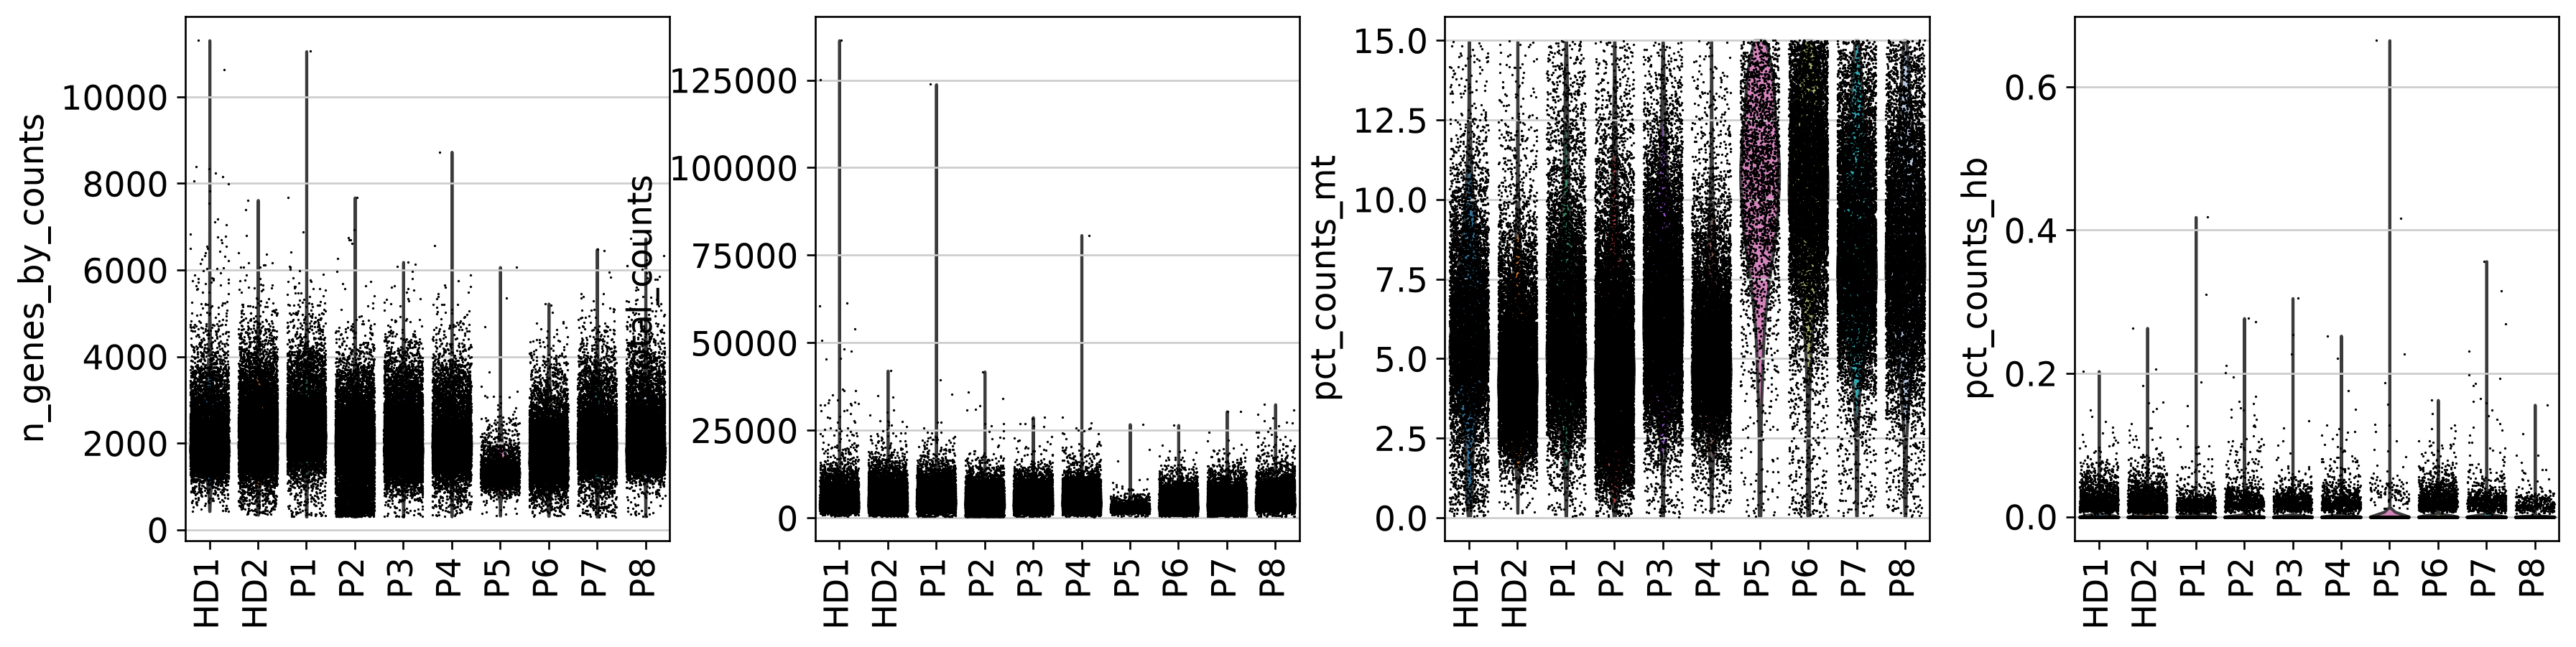

In [17]:
# Generate QC violin plots for each individual sample

sc.pl.violin(
    adata,
    [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "pct_counts_hb"
    ],
    groupby="sample",
    jitter=0.4,
    multi_panel=True,
    rotation=90
)

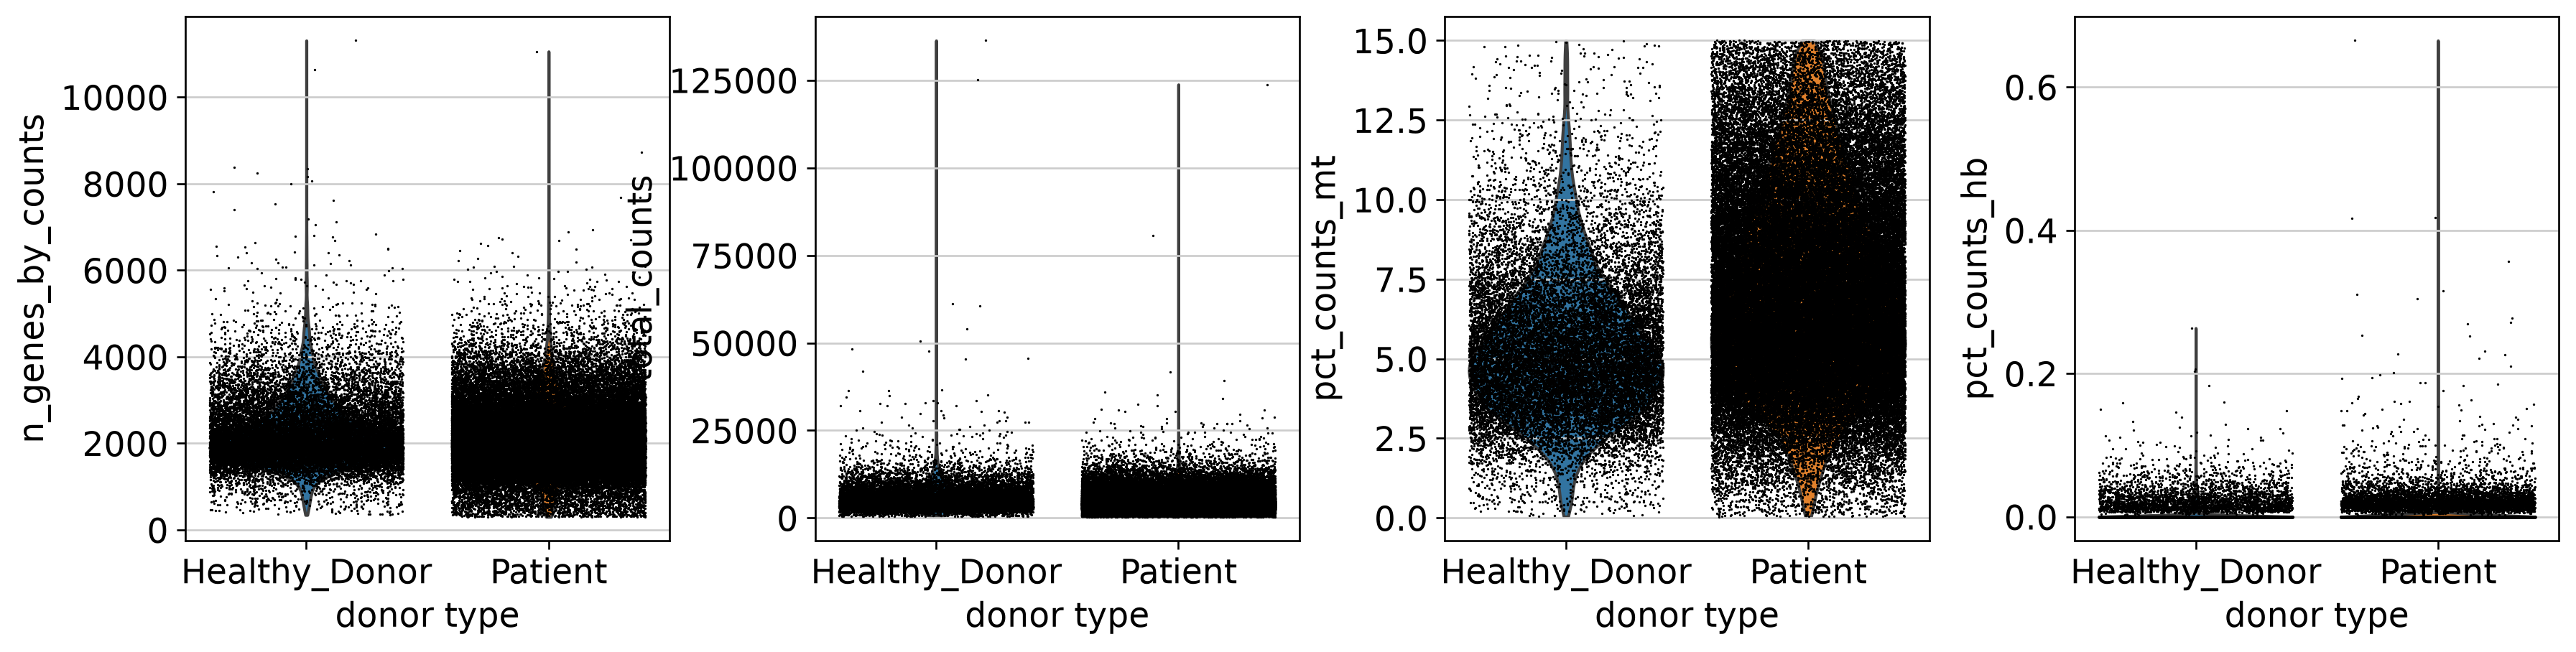

In [18]:
sc.pl.violin(
    adata,
    [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "pct_counts_hb"
    ],
    groupby="donor_type",
    jitter=0.4,
    multi_panel=True
)

In [4]:
adata.obs[
    [
        "n_genes_by_counts",
        "total_counts",
        "pct_counts_mt",
        "pct_counts_ribo",
        "pct_counts_hb"
    ]
].describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo,pct_counts_hb
count,94513.000000,94513.000000,94513.000000,94513.000000,94513.000000
mean,2102.129633,4943.688477,6.772288,3.092707,0.002480
std,712.498918,2858.925781,3.018094,2.719732,0.010673
min,301.000000,334.000000,0.032321,0.000000,0.000000
25%,1670.000000,3273.000000,4.539125,1.259061,0.000000
50%,2003.000000,4320.000000,6.328233,2.232262,0.000000
75%,2420.000000,5880.000000,8.715163,4.012794,0.000000
max,11306.000000,136339.000000,14.998391,53.267567,0.664820


In [5]:
qc_summary = (
    adata.obs
    .groupby("sample")
    [
        [
            "n_genes_by_counts",
            "total_counts",
            "pct_counts_mt",
            "pct_counts_hb"
        ]
    ]
    .median()
)

qc_summary

/tmp/ipykernel_10306/3882379110.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("sample")


,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_hb
sample,,,,
HD1,2041.0,4434.0,5.791857,0.0
HD2,2084.0,4253.0,4.600699,0.0
P1,2308.5,5291.0,5.791340,0.0
P2,1939.0,4133.0,4.923367,0.0
P3,2016.0,4389.5,6.554592,0.0
P4,2009.5,4619.0,5.147215,0.0
P5,1344.0,2633.0,10.542797,0.0
P6,1711.5,3528.5,10.365805,0.0
P7,1990.0,4053.0,8.474369,0.0
